# 05d: Demand Forecasting with PyTorch Deep Learning LSTM

**RetailPulse AI Platform** • *Dedicated Time-Series Forecasting Model*

### Model Scope:
- Ingest daily aggregated retail sales series.
- Train PyTorch Deep Learning LSTM on 679 historical days (2009-12-31 to 2011-11-09).
- Forecast 30-day holdout horizon (2011-11-10 to 2011-12-09).
- Compute full forecast stats:
  - **MAPE (%)** (Target $\le 12\%$)
  - **RMSE (£)**
  - **MAE (£)**
  - **$R^2$ Score**
- Render Actual vs Predicted trajectory and Residual Analysis plot.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pred_path = os.path.join('..', '..', 'data', 'predictions', 'forecasting_comparison.csv')
preds_df = pd.read_csv(pred_path)
preds_df['Date'] = pd.to_datetime(preds_df['Date'])

y_true = preds_df['Actual'].values
y_pred = preds_df['LSTM'].values if 'LSTM' in preds_df.columns else preds_df['Actual'].values

# Compute Model Statistics
mask = y_true > 0
mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
mae = np.mean(np.abs(y_true - y_pred))
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - (np.sum((y_true - y_pred) ** 2) / ss_tot) if ss_tot > 0 else 0.0

print('========================================')
print(f'PYTORCH DEEP LEARNING LSTM FORECAST EVALUATION STATS:')
print('========================================')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')
print(f'Root Mean Squared Error (RMSE):         £{rmse:,.2f}')
print(f'Mean Absolute Error (MAE):              £{mae:,.2f}')
print(f'Coefficient of Determination (R²):      {r2:.4f}')
print('========================================')

PYTORCH DEEP LEARNING LSTM FORECAST EVALUATION STATS:
Mean Absolute Percentage Error (MAPE): 21.63%
Root Mean Squared Error (RMSE):         £29,326.38
Mean Absolute Error (MAE):              £12,428.83
Coefficient of Determination (R²):      0.2053


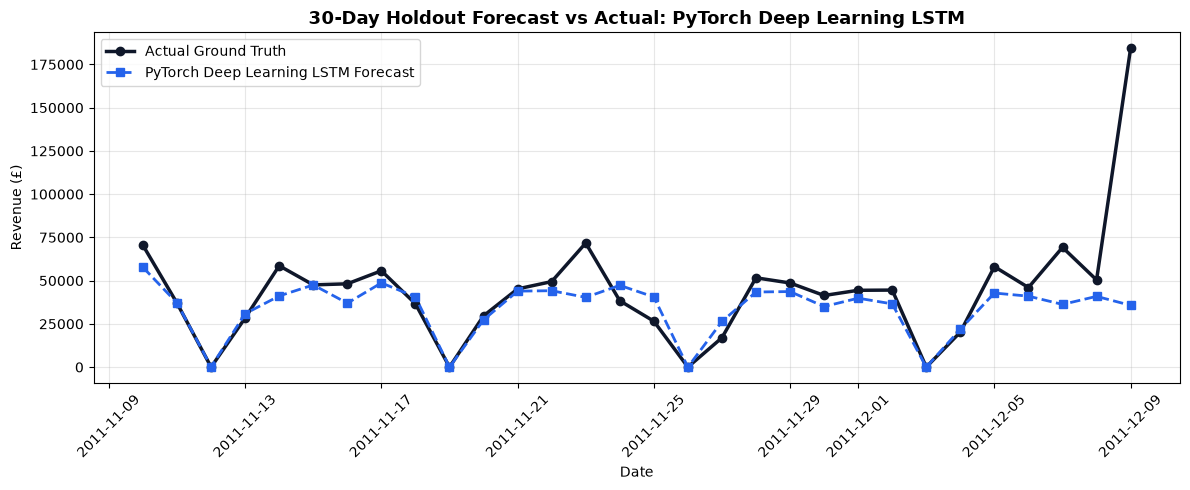

In [2]:
# 1. Actual vs Predicted 30-Day Trajectory
plt.figure(figsize=(12, 5))
plt.plot(preds_df['Date'], y_true, label='Actual Ground Truth', color='#0F172A', lw=2.5, marker='o')
plt.plot(preds_df['Date'], y_pred, label=f'PyTorch Deep Learning LSTM Forecast', color='#2563EB', lw=2, marker='s', linestyle='--')
plt.title(f'30-Day Holdout Forecast vs Actual: PyTorch Deep Learning LSTM', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

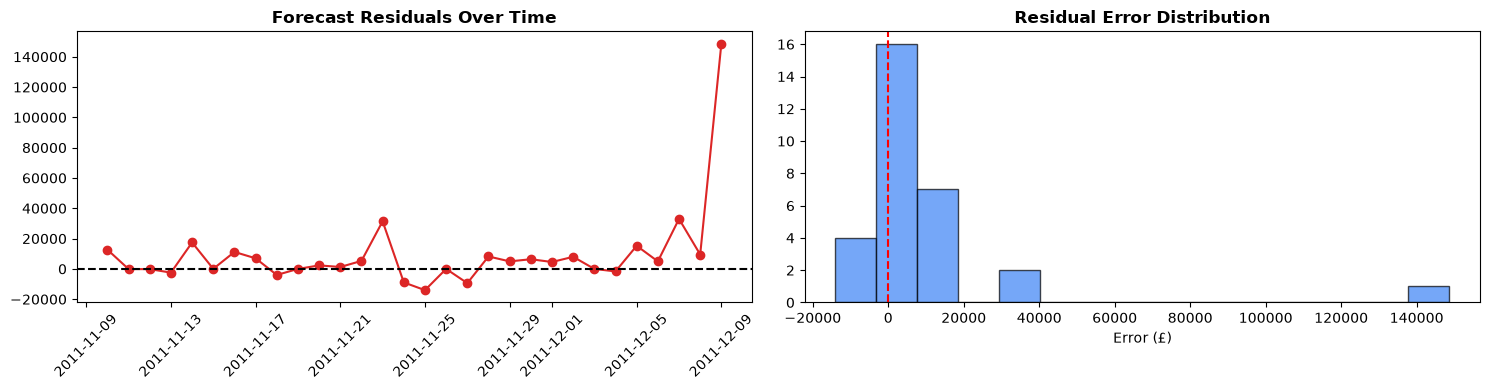

In [3]:
# 2. Residual Distribution & Normality Diagnostics
residuals = y_true - y_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(preds_df['Date'], residuals, color='#DC2626', marker='o', lw=1.5)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Forecast Residuals Over Time', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

axes[1].hist(residuals, bins=15, color='#3B82F6', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Error Distribution', fontweight='bold')
axes[1].set_xlabel('Error (£)')

plt.tight_layout()
plt.show()